# 全局联邦学习算法对比分析 (Global FL Analysis)

本 Notebook 用于对比分析传统的全局联邦学习算法（如 FedAvg, FedProx, Scaffold 等）在相同实验配置下的性能表现。

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt

# 添加项目根目录到路径
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from plot.utils import load_plot, load_plot_all_runs, ResultLoader

In [2]:
# --- 实验组定义 ---
experiments = {
    # 基础算法
    "FedAvg": ("fedavg", {}),
    "FedProx": ("fedprox", {"mu": 0.01}),
    "Scaffold": ("scaffold", {"global_lr": 1.0}),
    "FedDyn": ("feddyn", {"alpha_coef": 0.1}),

    # 进阶/特征对齐算法
    "FedProc": ("fedproc", {}),
    "FedFM": ("fedfm", {"mu": 0.1}),
    "MOON": ("moon", {"mu": 0.01, "tau": 0.5}),
    "FedPLN": ("fedpln", {"lambda_": 10.0, "epoch_pln": 10, "lr_pln": 0.01, "batch_size_pln": 64, "depth_pln": 1, "width_pln": 512, "mode": "normal", "fixed_proto": 0, "init_emb": 0, "har": 0}),
    "FedLSA": ("fedlsa", {"lambda_com": 0.1, "alpha_sep": 0.1, "server_epochs": 10, "server_lr": 0.01, "tau": 0.1})
}

# --- 通用参数 ---
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "rounds": 200,
    "epochs": 10,
    "lr": 0.01,
    "batch_size": 64
}

loader = ResultLoader(base_dir="../results_ray")

Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
FedAvg               |         67.7417 |         67.3992
FedProx              |         67.4250 |         67.0250
Scaffold             |         68.9083 |         66.0183
FedDyn               |         68.3333 |         67.7808
FedProc              |         64.3250 |         62.7183
FedFM                |         66.6500 |         66.0208
MOON                 |         67.3333 |         66.5300
FedPLN-Model         |         71.9167 |         71.7317
FedPLN-Proto         |         71.8917 |         71.6767
FedLSA               |         42.5833 |         41.8192
-----------------------------------------------------------------


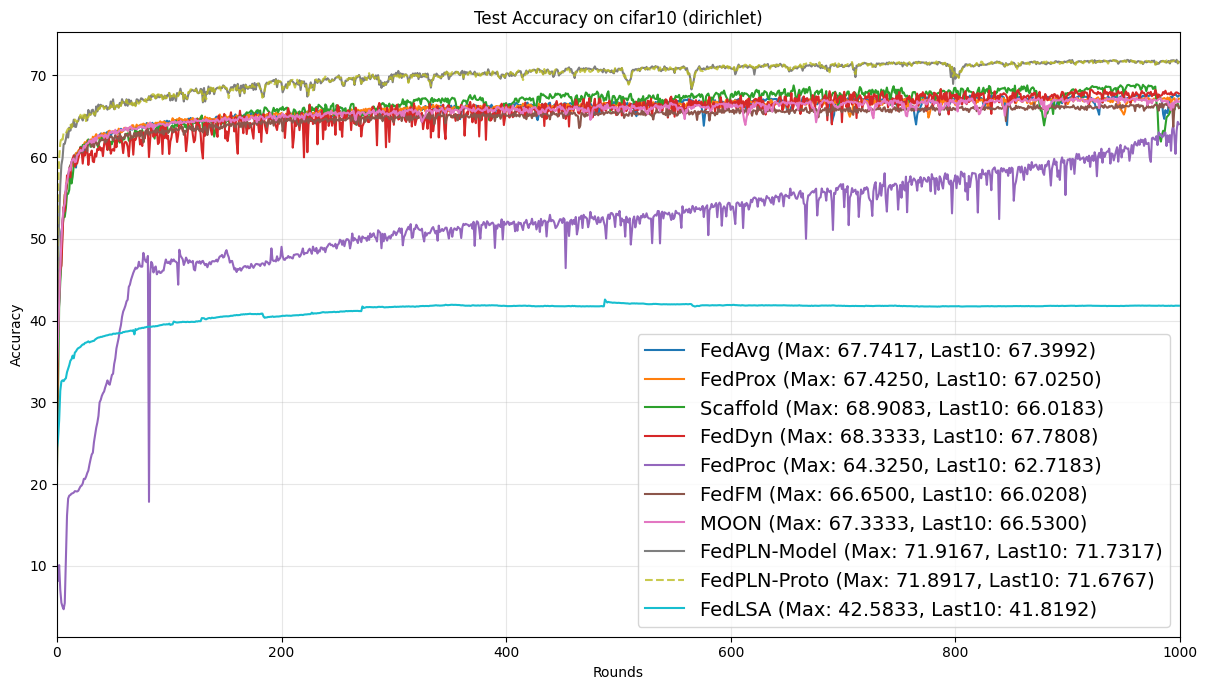

In [3]:
# 1. 加载并绘制曲线 (Run 0)
load_plot(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=1000
)

In [4]:
# 2. 统计所有 Run 的平均性能
load_plot_all_runs(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=200
)


Summary of ALL RUNS (Mean ± Std):
---------------------------------------------------------------------------
Algorithm                 |              Max Acc |          Last 10 Avg
---------------------------------------------------------------------------


FedAvg                    |  65.4483 ± 0.0744  |  65.1173 ± 0.0903  (5 runs)
FedProx                   |  65.4867 ± 0.0983  |  65.2807 ± 0.0915  (5 runs)
Scaffold                  |  66.0683 ± 0.0718  |  65.2873 ± 0.4304  (5 runs)
FedDyn                    |  65.6333 ± 0.1273  |  63.9805 ± 0.3255  (5 runs)
FedProc                   |  50.1350 ± 1.2480  |  48.3527 ± 0.7338  (5 runs)
FedFM                     |  64.5233 ± 0.1739  |  64.0395 ± 0.2228  (5 runs)
MOON                      |  65.2917 ± 0.1613  |  64.8877 ± 0.1070  (5 runs)
FedPLN-Model              |  69.5667 ± 0.0000  |  69.2483 ± 0.0000  (1 runs)
FedPLN-Proto              |  69.4083 ± 0.0000  |  69.1583 ± 0.0000  (1 runs)
FedLSA                    |  41.0883 ± 0.3014  |  40.9532 ± 0.3456  (5 runs)
